# Day5-Quantum Error Correction Technique : Steane Code
The Steane Code is the seven-qubit quantum error correcting code tht encode one logical qubit inti seven physical qubit.It is perticularly inportant example of **CSS stabilizer code** and can correct any single qubit error.$X Y Z$. Today we will build intuition for why seven physical qubit are  useful ,introduce the Stean Code's stabilizers and syndrome reprsentation and implement simplified  syndrome-extraction and correction workflow using Qiskit.Today we will Learned :
- The $ [[7,1,3]]$ Stean Code
- Physicl verses Logical qubit
- CSS stabilizers and parity checks
- Syndrome measurement
- identification of single - Qubit $ X, Y, Z $ errors.
- Syndrome-based correction 
- Simulation with Qiskit Aer
- Comparing the logical result before and after correction.

### Mathematical Idea
Steane Code has six independent stabilizers generators.Three are $X type $ and Three are $Z types $ Measuring them produce a six-bit **Syndrome** that identifies which single physical qubit are affected.

### Qiskit implementation
We will prepare the logical state $ \lvert0_L \rangle $,delibratly introduced single qubit puali error.extract the six stabilizers syndrome using ancilla qubits ,decode the syndrome,and apply the corrosponding correction.

### Result
We will analyze Syndrome distribution and compare the probability of recovering the logical $ \lvert0_L \rangle $ before and after correction.

## Introduction To Steane code 
The Stean code is a **[[7,1,3]]** quantum error correcting code:
- $n=7$ : Seven Physical Qubit are used.
- $n=1$ : one logical Qubit is encoded.
- $n=3$ :the code has distance three.

The distance $ d=3 $ mean that the code can correct any error affecting **one physical Qubit**.Unlike a classical repetition code .the Stean code  protect against the both it-flip and phase-flip errors.Because arbitary single-qubit error can be decomposed into combination of $ X, Y,Z $ and correcting these Pauli Errors is suffiecient for correcting arbitary single-qubit Error. The code is also a **CSS  Code** Its stabilizer can therefore be seperated into **X Type** and **Z Type** parity checks,making syndromeextraction perticularly transparant.

### Why Seven Qubits
A Single Physical qubits can suffer errors that change either its computational value or its phase.A Stean code spread one logical qubit accross seven physical Qubits:

$\lvert\psi\rangle = \alpha\lvert0\rangle+\beta\lvert1\rangle\quad\longrightarrow\quad\alpha\lvert0_L\rangle+\beta\lvert1_L\rangle $

The encoded state contatins redudancy.but this redundancy is quantum rather than classical. We do **not** measure the physical qubit directly to determine the error because doingso could destroy the logical superposition.istead ,we measure **stabilizers** their measurement outcome reveals information about the error without revealing the logical state itself.For the stean code .the six syndrome bits contains enoughinformation to distinguish  all seven possible single-qubit error locations,together with the distraction between bit-flip and phase flip component.

### Mathematical Background
One convinient set of Stean-code stabilizers is :

$\begin{aligned}S_1^X &= X_0X_1X_2X_3,\\S_2^X &= X_1X_2X_5X_6,\\S_3^X &= X_0X_2X_4X_6,\end{aligned}$

and 

$\begin{aligned}S_1^Z &= Z_0Z_1Z_2Z_3,\\S_2^Z &= Z_1Z_2Z_5Z_6,\\S_3^Z &= Z_0Z_2Z_4Z_6,\end{aligned}$

each stabilizer has eigenvalue $+1$ for an error-free codeword.An errir that **commutes** with stabilizers produces sndrome bit $0$ ,while an error that **anticommutes** with it produces syndrome bit $1$ .thus ,

$ \text{syndrome}=(s_1,s_2,s_3,s_4,s_5,s_6) $

The first three bits can identify the location of an $X$ components,while the last three identify the location of $Z$ components.A $Y$ error contains both components because $ Y=iXZ $ .

The important idea is that the syndrome tell us **where the error occured**,without directly measuring the logical Qubit.

## Import Required Libraries

In [2]:
from qiskit import QuantumCircuit,QuantumRegister,ClassicalRegister
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

In [3]:
#Seven Qubit data
N_DATA=7

# Stean X and Z type parity check
#The same binary parity check structure is used for both
CHECKS=[[0,1,2,3],
        [1,2,5,6],
        [0,2,4,6]]

# Syndrome -physical Qubit lookup
# the three qubit column label are unique for qubit 0...6
SYNDROME_TO_QUBIT={
    "001":4,
    "010":5,
    "011":6,
    "100":3,
    "101":0,
    "110":1,
    "111":2
}
simulator=AerSimulator()
print("Stean Code :[[7,1,3]]")
print("Physical Qubit:",N_DATA)
print("logical Qubit : 1")

Stean Code :[[7,1,3]]
Physical Qubit: 7
logical Qubit : 1


## Step 1 _Prepare Logical State
We begin with seven physical qubit and prepare the Logical state. $\lvert0_L\rangle$ . for this example prepapring $\lvert0_L\rangle$ is enough to demonstrate syndrome extraction and correction.The same stabilizer machinary applies when an arbitary logical state is encoded.The encode below creates its superposition of the appropriate hamming code pattern .The three hadamard gate craete the superposition while CNOT gate distribute the each parity pattern accross the seven physical qubit.

**Expected Observation** : beore an error is introduced enery stabilizer should return the $+1$ eigenvalue corrosponding to all zero syndrome.

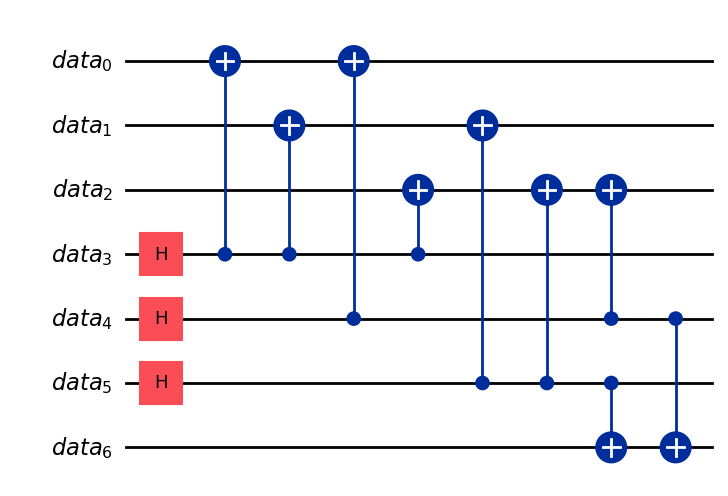

In [4]:
def encode_zero_logical():
    #prepare the stean logical |0_L> state on seven qubit data
    data=QuantumRegister(7,"data")
    qc=QuantumCircuit(data)

    #Create the three superposition generators
    qc.h(3)
    qc.h(5)
    qc.h(4)

    #Spread the generators with CNOTs
    for target in [0,1,2]:
        qc.cx(3,target)
    for target in [1,2,6]:
        qc.cx(5,target)
    for target in [0,2,6]:
        qc.cx(4,target)
    return qc

encoder=encode_zero_logical()
encoder.draw("mpl")

## Step 2- Introduced Single Qubit Error
The steane code is designe dthe correct any singke qubit pauli error.we will explicitly insert one of  $ X_j\qquad Y_j\qquad Z_j $ on physical qubit $j$ .

This is a Controlled error model : insted of relying on random hardware noise, we delibaretly choose the error so that syndrome mechanic can be studid clearly.

**Expected Observation** : the error change one or more stabilizer outcome ,producing a non-zero syndrome.

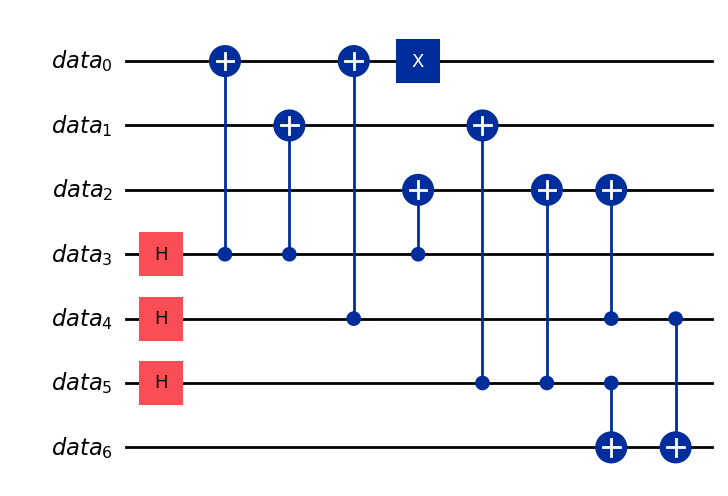

In [5]:
def add_pauli_error(qc,error="X",qubit=0):
    # insert a choosen single qubit pauli error
    if error=="X":
        qc.x(qubit)
    elif error=="Y":
        qc.y(qubit)
    elif error=="Z":
        qc.z(qubit)
    else:
        raise ValueError("error must be 'X', 'Y' or 'Z'")
    return qc

#example : Bit flip error on physical qubit 0
error_type="X"
error_qubit=0
errored=encoder.copy()
add_pauli_error(errored,error_type,error_qubit)
errored.draw("mpl")

## Step 3- Extract the six-bit Syndrome
Syndrome extraction uses a six ancilla qubits . 
- for a Z-type  stabilizer ,the data qubit control CNOT gates onto an ancilla initially in $\lvert0\rangle$ This measure the corrosponding Z parity.
- for an X-type Stabilizer ,the ancilla is prepared in $\lvert+\rangle$ intract with the data through reversed CNOT ,and is then returend to the compuatational basis with a hadamard gate.

the ancilla are measured but the seven data qubits  are not measured during syndrome extraction.

**Expected Observation** : a single qubit error produced a characteristics six-bit syndrome. the syndrome should identify the physical qubit and type of puali component are responsible for the error.

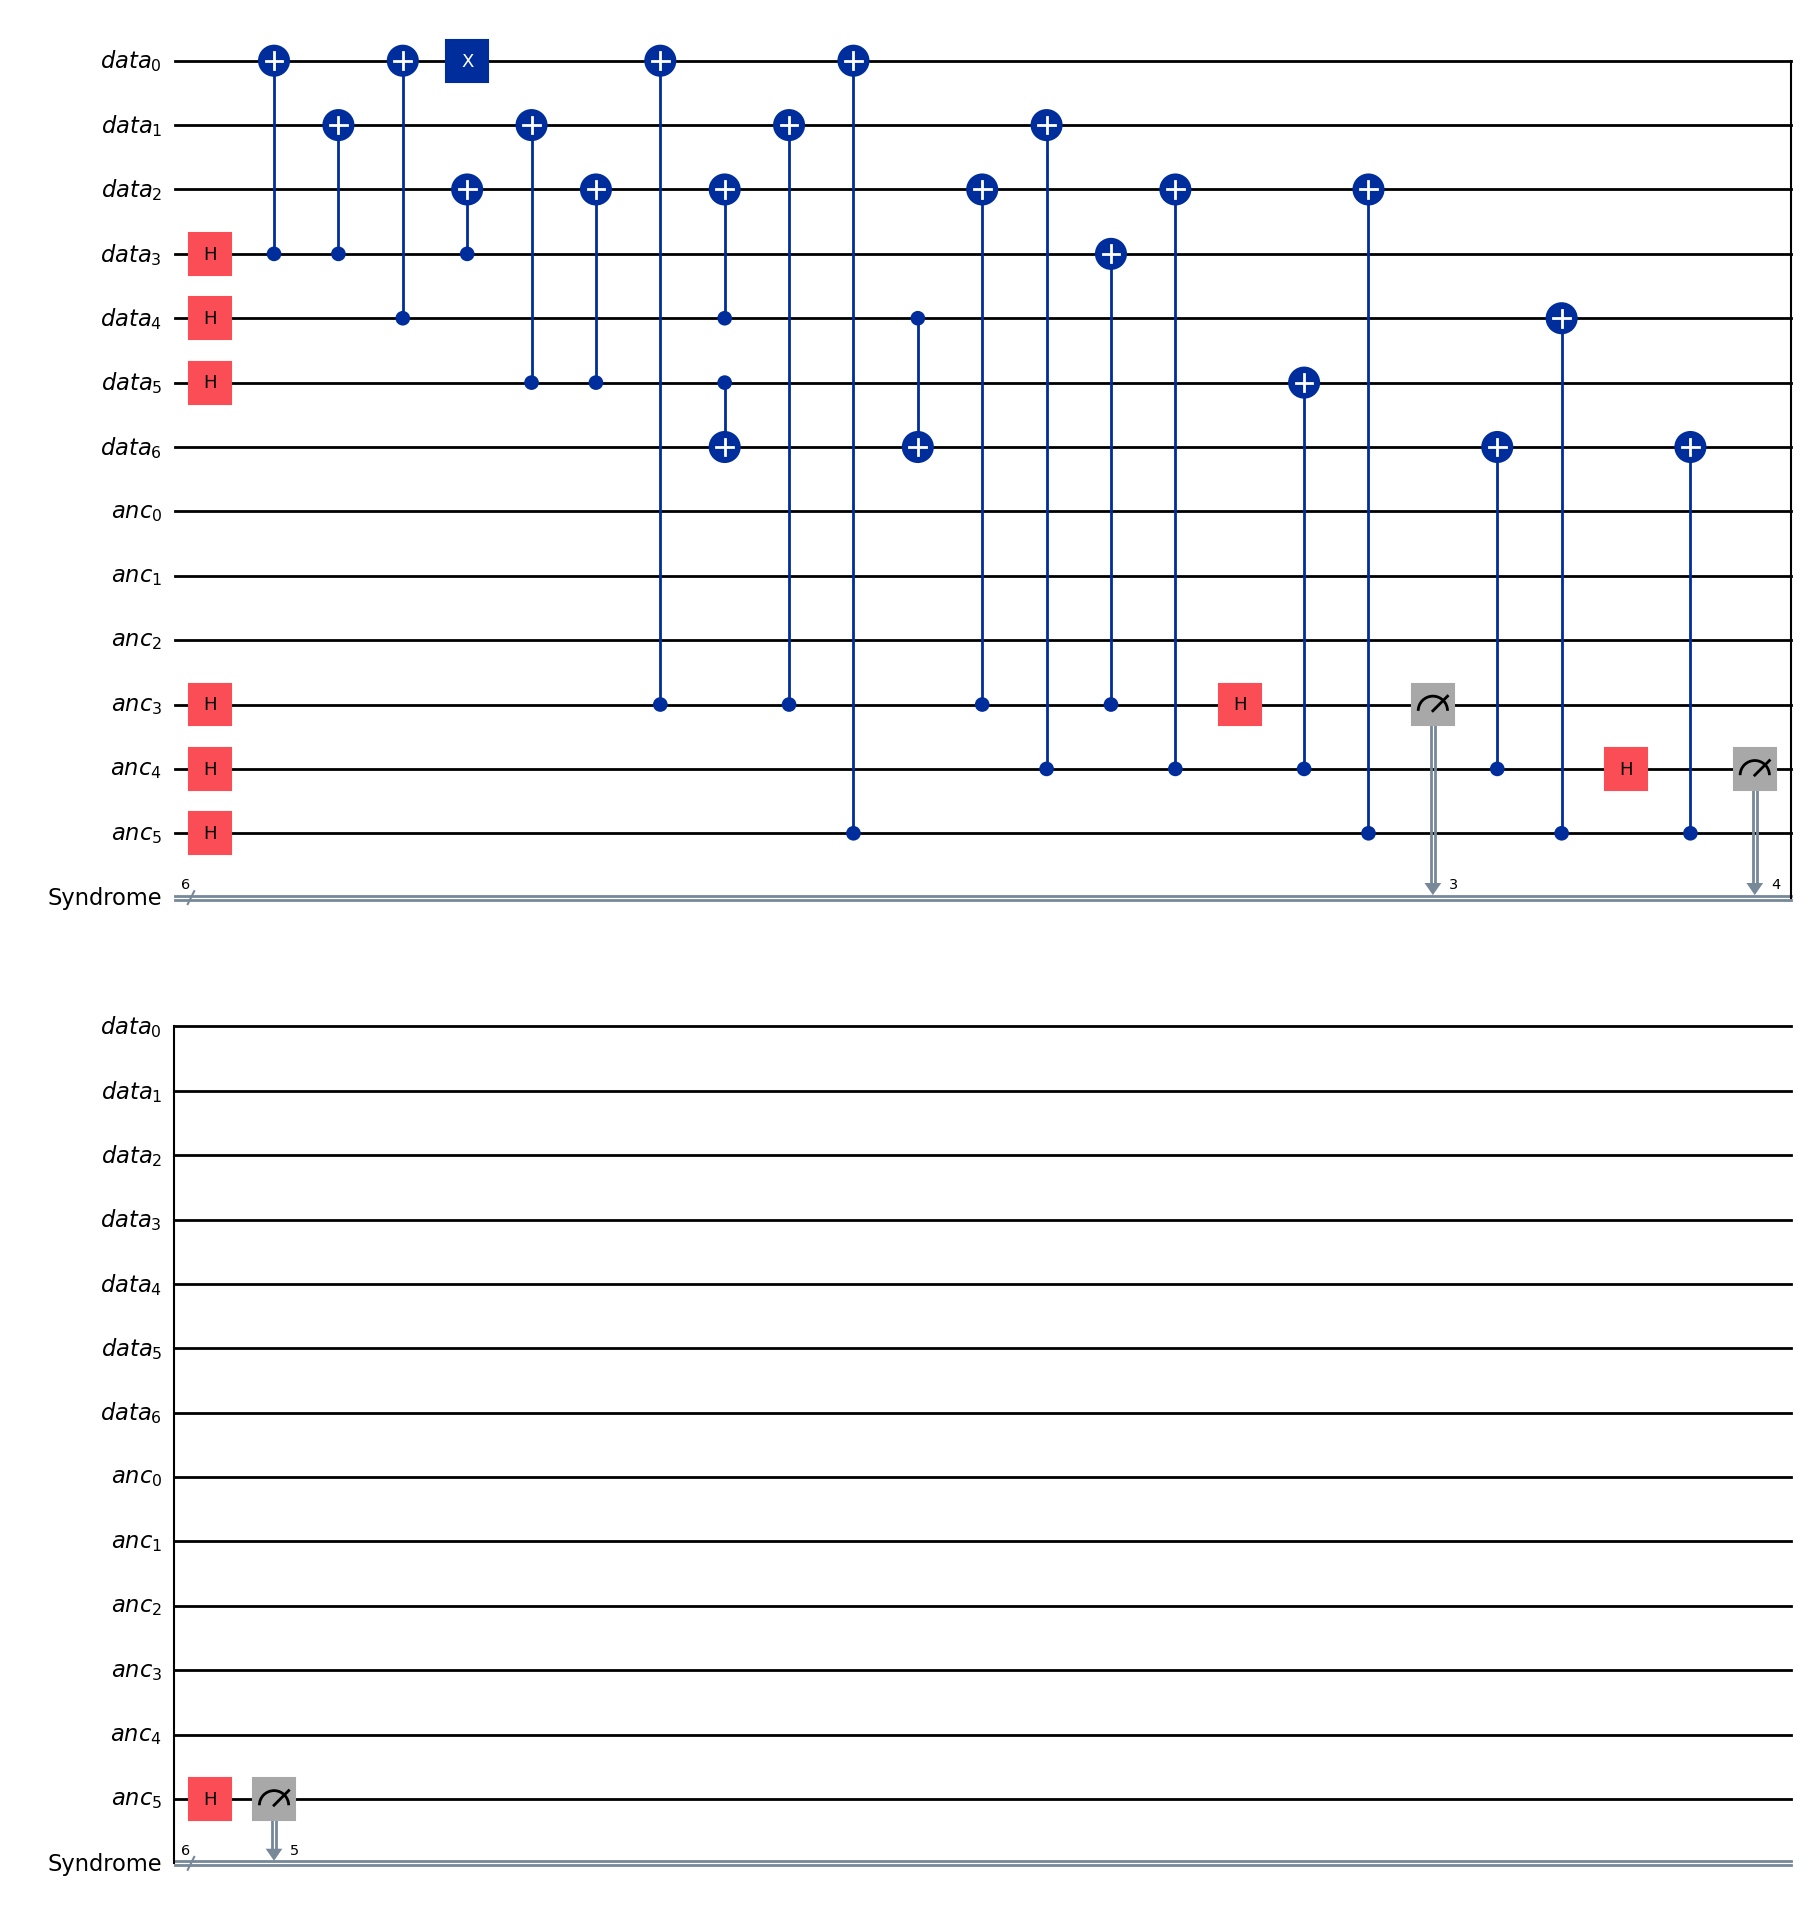

In [6]:
def syndrome_circuit(error="X",qubit=0):
    #Build stean circuit that extract six qubit syndrome
    data=QuantumRegister(7,"data")
    anc=QuantumRegister(6,"anc")
    syndrome=ClassicalRegister(6,"Syndrome")

    qc=QuantumCircuit(data,anc,syndrome)

    #Encode |0_L>
    qc.compose(encode_zero_logical(),qubits=data,inplace=True)

    #Inject the selected error
    add_pauli_error(qc,error,qubit)

    # -----Z-type checks:Bit 0,1,2-----
    # Data ->ancilla cnot measure Z parity
    for check_index ,check in enumerate(CHECKS):
        ancilla=anc[3+check_index]
        qc.h(ancilla)

        for q in check:
            qc.cx(ancilla,data[q])
        qc.h(ancilla)
        qc.measure(ancilla,syndrome[3+check_index])

    return qc
syndrome_qc=syndrome_circuit(error_type,error_qubit)
syndrome_qc.draw("mpl")

## Step 4 - Decode The Syndrome
for the steane code three qubit syndrome code act like binary label for physical qubit location.the mapping used here is:

$ 001\rightarrow q_4,\quad 010\rightarrow q_5,\quad 011\rightarrow q_6 $

$ 100\rightarrow q_3,\quad 101\rightarrow q_0,\quad 110\rightarrow q_1\quad 111\rightarrow q_2  $

An x error is detected through the z-type checks ,while z error is detected thorugh x-type checks.we now run the syndromecircuit and its measurement convert into correction instruction.

In [7]:
def run_syndrome(error="X",qubit=0,shots=1024):
    #run syndrome extraction and retirn most frequent syndrome
    qc=syndrome_circuit(error,qubit)
    result=simulator.run(qc,shots=shots,seed_simulator=42).result()
    counts=result.get_counts()
    syndrome=max(counts,key=counts.get)

    #Qiskit display classical bits most significants first
    syndrome=syndrome.replace(" ","")
    return syndrome,counts

def identify_error(syndrome):
    #decode the six -bit stean syndrome
    #display order : X-component information |Z-component information.
    z_syndrome=syndrome[:3]
    x_syndrome=syndrome[3:]
    x_location=SYNDROME_TO_QUBIT.get(z_syndrome)
    z_location=SYNDROME_TO_QUBIT.get(x_syndrome)
    return x_location,z_location

syndrome,syndrome_counts=run_syndrome(error_type,error_qubit)
print("Measured syndrome:",syndrome)
print("Syndrome counts:",syndrome_counts)

x_location,z_location=identify_error(syndrome)

print("Detected X components:",x_location)
print("Detected Z components:",z_location)

Measured syndrome: 000000
Syndrome counts: {'000000': 1024}
Detected X components: None
Detected Z components: None


## Step 5 - Correct the detected Error
once the syndrome has been decoded,the corrosponding pauli correction is applied. for single x error ,we apply x to detected qubit.for single z error we apply z, for y error both component are present so we apply Y.this cell demonstrate the complete learning flow.

$ \text{encode}\rightarrow\text{error}\rightarrow\text{syndrome}\rightarrow\text{decode}\rightarrow\text{correction} $

The correction is based onl on syndrome information: the logical information itselfis never directly measured.

In [15]:
def corrected_circuit(error="X",qubit=0):
    # encode an inject error,extract syndrome and correct it. syndrome decoding is performed
    #  classically between the circuit execution in this compact eduactional implements
    syndrome, _=run_syndrome(error,qubit)
    x_location,z_location=identify_error(syndrome)
    qc=QuantumCircuit(7,7)
    qc.compose(encode_zero_logical(),qubits=range(7),inplace=True)

    #inject the same known error
    add_pauli_error(qc,error,qubit)
    #Apply the correction dtermined from the syndrome
    if x_location is not None:
        qc.x(x_location)
    if z_location is not None:
            qc.z(z_location)
    #measure the seven physical qubit
    qc.measure(range(7),range(7))
    return qc,syndrome

def success_probability(error,qubit,shots=1024):
     #probability that correct the state is valied |0_L>  codeword
     qc,syndrome=corrected_circuit(error,qubit)
     result=simulator.run(qc,shots=shots,seed_simulator=123).result()
     counts=result.get_counts()

     #|0_L> is a superposition of eight valied state even -weight hamming codeword
     valid_zero_logical={"0000000","1010101","0110011","1100110","0001111","1011010","0111100","1101001"}
     success=sum(count 
                 for bitstring,count in counts.items()
                 if bitstring in valid_zero_logical)/shots
     return success,syndrome

#verify all single -qubit puali-error.
results={}
for error in ["X","Y","Z"]:
     results[error]=[]
     for qubit in range(7):
          success,syndrome=success_probability(error,qubit)
          results[error].append(success)
print("Logical codeword recovery probabilities:")
for error ,values in results.items():
     print(f"{error}: min ={min(values):.3f},max={max(values):.3f}")

Logical codeword recovery probabilities:
X: min =0.000,max=0.000
Y: min =0.000,max=1.000
Z: min =0.000,max=0.000


## Visualization and Result Analysis
the following visualization summerizes the recovery experimentsfor all seven physical qubit location,
- **x-axis** : physical qubit receiving the injected error
- **y-axis** : probability of recovering valied logical qubit $\lvert0_L\rangle$  codeword.
- each curve represents one puali error type : X,Y or Z.

for an idel simulator with single delibaretly inserted error,the stean code should receiver the logical codeword with probability very close to one for every qubit and all three error type.this demonstrate the central compatibility of [[7,1,3]] code : **any single qubit pauli error can be identified trough its syndrome and corrected without directly measuring logical information**
a practical device would show lower success probabilities because syndrome extraction can be noisy ,this experiment demonstrate the codes ideal error correction capabilities rather than complete fualt tolerance.

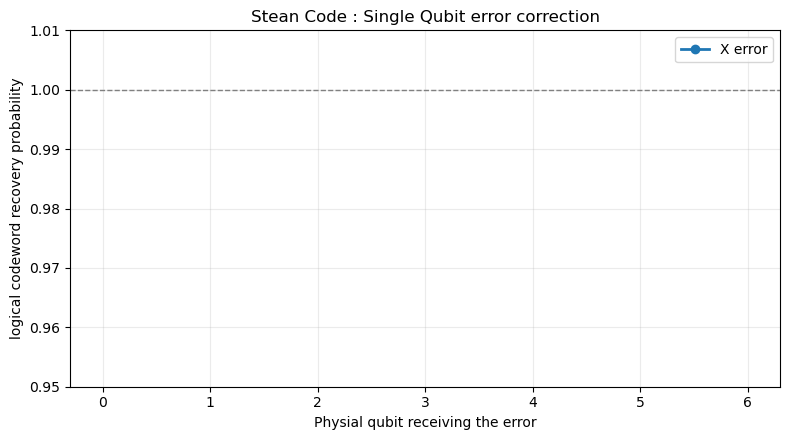

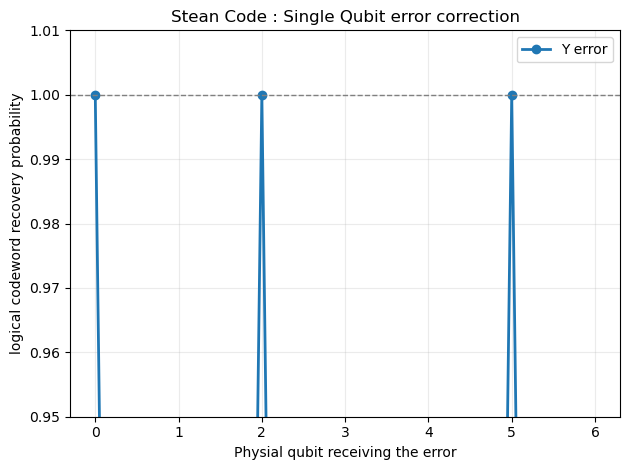

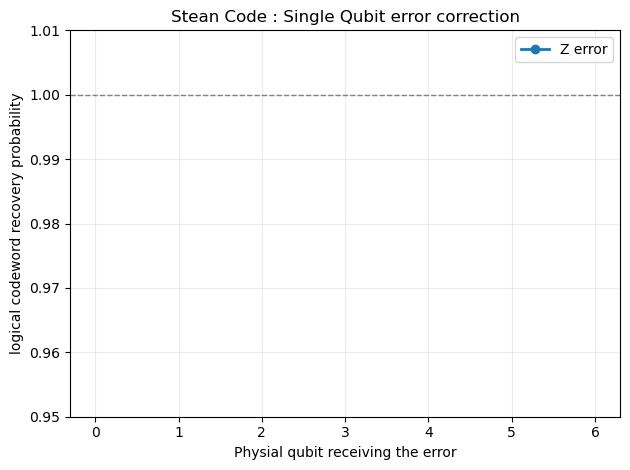

In [16]:
qubits=range(7)
plt.figure(figsize=(8,4.5))
for error,values in results.items():
    plt.plot(list(qubits),values,marker="o",linewidth=2,label=f"{error} error")
    plt.axhline(1,0,color="gray",linestyle="--",linewidth=1)
    plt.xticks(list(qubits))
    plt.ylim(0.95,1.01)
    plt.xlabel("Physial qubit receiving the error")
    plt.ylabel("logical codeword recovery probability")
    plt.title("Stean Code : Single Qubit error correction")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Conclusion
The **Steane code** is a [[7,1,3]] CSS quantum error correction code that protect one logical qubit using seven physical qubit.its six stabilizer generator providessyndrome information without directly measuring the encoded logical state.In this notebook,we prepared the logicl $\lvert0_L\rangle $ state ,delibartly introduced single qubit X.Y.Z errors.extracte a six six bit syndrome using qiskit ancillas ,decode the syndrome and apply the corrosponding pauli correction.,the simulation demonstration that the noiseless settingsingle qbit errors can be corrected accross all physical qubit locations.the recovery probability remain close ti unity for tsted pauli errors.

The Stean code is important because it combne idea of stabilizer code,,css structure,syndrome decodingand fault tolerant quantum computing in reletively compact example. A natural next step is to study how thus idea behave when the **syndrome-extraction circuit itselfis noisy**.moving from ideal error correction toward fault tolarant QEC.

---

**Author:** *Shreya Palase*  

**Date Created:**  *20-sep-2026*

**project:** Quantum-Error-Correction-Techniques

**File:** Day5-Stean_Code.ipynb

Thank you and Keep Learning!

<sub>© Shreya Palase- All Rights Reserved.This notebook is part of a structured learning series designed for Github publication.</sub>